> 딥러닝 파이토치 교과서 5장 p.179-200

## 5.2 합성곱 신경망 맛보기

fashion_mnist 데이터셋을 사용해 합성곱 신경망 직접 구현해보기  

예제 데이터(운동화, 셔츠, 샌들 같은 작은 이미지의 모음)  
0~9까지 정수값은 이미지의 클래스를 나타냄



In [1]:
# 라이브러리 호출

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms  # 데이터 전처리를 위해 사용하는 라이브러리
from torch.utils.data import Dataset, DataLoader

아직 GPU 설정 안했으니까 CPU 사용할 것

In [2]:
# CPU 혹은 GPU 장치 확인

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

- 하나의 GPU 사용할 때

`device = torch.device( "cuda :0" if torch .cuda.is_available() else "cpu" )  
model = Net ( )  
model. to( device)`

- 다수의 GPU 사용할 때

`device = torch .device( "cuda" if torch.cuda.is_available() else "cpu" )  
model = Net()  
  if torch.cuda .device_count() > 1:  
  model = nn.DataParallel(net)  
model. to( device) `

단, GPU 수만큼 배치 크기도 늘려 주어야 함




In [3]:
# fashion_mnist 데이터셋 내려받기

train_dataset = torchvision.datasets.FashionMNIST('../chap05/data', download=True,
                                                  transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST('../chap05/data', download=True,
                                                 train=False, transform=transforms.Compose([transforms.ToTensor()]))
# 앞에서 훈련 데이터셋을 내려받았다면 여기에서는 테스트 데이터셋을 내려받음

100%|██████████| 26.4M/26.4M [00:01<00:00, 19.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 307kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.65MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 21.3MB/s]


파라미터
- 1st: 내려받을 위치 지정
- download: True일 때 첫 번째 파라미터 위치에 데이터셋 있는지 확인하고 내려받음
- transform: 이미지를 텐서(0~1)로 변경


In [4]:
# fashion_mnist 데이터를 데이터로더에 전달

train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size = 100)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size = 100)

 `torch.utils.data.DataLoader()`: 원하는 크기의 배치 단위로 데이터 불러오기 / 순서 무작위 셔플 가능하게 함

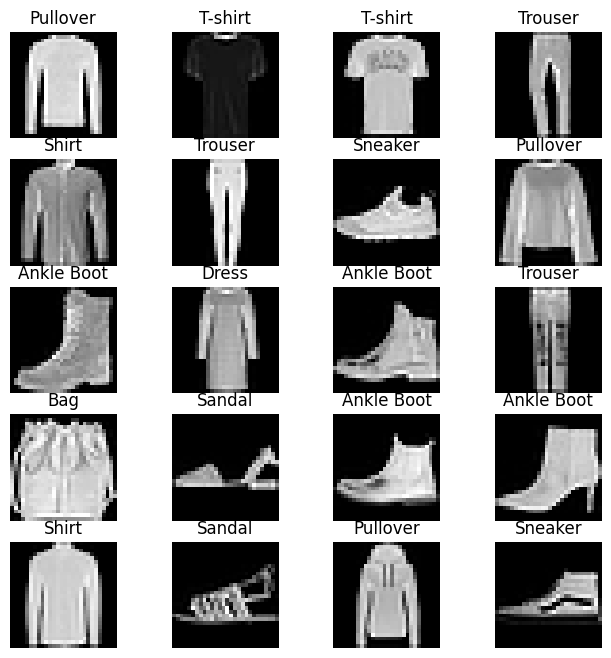

In [5]:
# 분류에 사용될 클래스 정의

labels_map = { 0: 'T-shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat', 5:'Sandal',
              6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'} # 열 개의 클래스

fig = plt.figure(figsize=(8,8)); # 출력할 이미지의 가로세로 길이로 단위는 inch
columns = 4;
rows = 5;
for i in range(1, columns*rows + 1):
  img_xy = np.random.randint(len(train_dataset));
  img = train_dataset[img_xy][0][0,:,:]
  fig.add_subplot(rows, columns, i)
  plt.title(labels_map[train_dataset[img_xy][1]])
  plt.axis('off')
  plt.imshow(img, cmap='gray')
plt.show()  # 20개의 이미지 데이터를 시각적으로 표현

- `np.random` : 무작위로 데이터를 생성할 때 사용.
-  `np.random.randint()` : 이산
형 분포를 갖는 데이터에서 무작위 표본을 추출할 때 시용

- `img = train_dataset[img_xy][0][0,:,:]` 의미  
해당 index의 요소 값을 가져오겠다는 뜻

In [6]:
# 심층 신경망 모델 생성

class FashionDNN(nn.Module):
  def __init__(self):  #1
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)  #2
    self.drop = nn.Dropout(0.25)  #3
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):  #4
    out = input_data.view(-1, 784)  #5
    out = F.relu(self.fc1(out))  #6
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

- #1  
__init__() : 객체가 갖는 속성 값 초기화  

- #2  
`nn` : 딥러닝 모델(네트워크) 구성에 필요한 모듈이 모여 있는 패키지  
입력 크기 / 출력 크기 파라미터 사용.  

- #3   
` nn.Dropout(p)` : p의 비율로 텐서의 값이 0이 됨. 0이 되지 않는 값들은 기존 값
에 (1/(1-p))만큼 곱해져 커짐.

- #4  
`forward()` : 순전파 학습 진행시킴. 반드시 'forward' 이름이어야 함.

- #5  
`view()`: 넘파이의 reshape와 같은 역할 - 텐서의 크기 변경  
-1은 미지정을 뜻함  

- #6  
활성화 함수 지정  

-
  - F.relu (): forward () 함수에서 정의
  - nn.ReLU(): __init__() 함수에서 정의


In [7]:
# 심층 신경망에서 필요한 파라미터 정의

learning_rate = 0.001;
model = FashionDNN();
model.to(device)

criterion = nn.CrossEntropyLoss(); # 분류 문제에서 사용하는 손실 함수
optimizer = torch.optim.Adam(model.parameters(), lr = learning_rate);  #1
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


- #1  
옵티마이저를 위한 경사하강법은 Adam 사용

In [8]:
# 심층 신경망을 이용한 모델 학습

num_epochs = 5
count = 0

loss_list = []  #1
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:  #2
    images, labels = images.to(device), labels.to(device) #3

    train = Variable(images.view(100, 1, 28, 28))  #4
    labels = Variable(labels)

    outputs = model(train) # 학습 데이터를 모델에 적용
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50): # count를 50으로 나누었을 때 나머지가 0이 아니라면 실행
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100, 1, 28, 28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total  #5
      loss_list.append(loss.data) #1'
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 500):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 500, Loss: 0.5619041323661804, Accuracy: 83.5%
Iteration: 1000, Loss: 0.4886742830276489, Accuracy: 84.79000091552734%
Iteration: 1500, Loss: 0.3560430109500885, Accuracy: 84.80000305175781%
Iteration: 2000, Loss: 0.3274669945240021, Accuracy: 85.44999694824219%
Iteration: 2500, Loss: 0.2652052938938141, Accuracy: 86.11000061035156%
Iteration: 3000, Loss: 0.27944236993789673, Accuracy: 86.62999725341797%


- #1, #1'  
일반적으로 배열이나 행렬과 같은 리스트를 사용하는 방법  
  - #1: 비어있는 배열, 행렬 제작
  - #2: append 메서드를 이용해 데이터 하나씩 추가

- #2  
for 문

- #3  
모델과 데이터가 동일한 장치(CPU/GPU)에 있어야 함.  

- #4  
Autograd는 자동 미분을 수행하는 파이토치의 핵심 패키지.  
자동 미분을 계산하기 위해서는 `torch.autograd` 패키지 안에 있는 Variable을 이용해야 동작함.  

- #5  
분류문제에 대한 정확도 계산(100곱하면 백분율)

* 단, 분류 문제에서 클래스가 3개 이상일 경우
  - 모든 클래스가 동등하게 고려된 건지/ 특정 클래스의 분류가 높았던 것인지 정확도만으로 알 수 X
  - 데이터 특성에 따라 정확도 관측 필요(원래부터 클래스 불균형일 경우)




In [9]:
# 합성곱 네트워크 생성

class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1=nn.Sequential(  #1
        nn.Conv2d(in_channels=1,out_channels=32,kernel_size=3,padding=1),  #2
        nn.BatchNorm2d(32),  #3
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,stride=2)  #4
    )
    self.layer2=nn.Sequential(
        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1=nn.Linear(in_features=64*6*6,out_features=600)  #5
    self.drop=nn.Dropout2d(0.25)
    self.fc2=nn.Linear(in_features=600,out_features=120)
    self.fc3=nn.Linear(in_features=120,out_features=10)  # 마지막 계층의out_features는 클래스 개수를 의미

  def forward(self,x):
    out=self.layer1(x)
    out=self.layer2(out)
    out=out.view(out.size(0),-1)  #6
    out=self.fc1(out)
    out=self.drop(out)
    out=self.fc2(out)
    out=self.fc3(out)
    return out

- #1  
nn.Sequential은 __init__()에서 사용할 네트워크 모델 정의 + forward() 함수에서 구현될 순전파를 계층 형태로 작성 가능(가독성 good)  

- #2  
  - 합성곱층: 합성곱 연산을 통해 이미지 특성 추출.
  - in_channels: 입력 채널의 수(흑백은 1, RGB는 보통 3)
  - out_chaennels: 출력 채널의 수
  - kernel_size: 커널 크기(=필터). 일반적으로 정사각형, 직사각형은 (3,5)처럼 지정.  
  - padding: 패딩 크기. 출력 크기 조정 위해 입력 데이터 주위에 0 채움. 패딩 값 클수록 출력 크기도 커짐

- #3
BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화하는 것

- #4  
MaxPool2d: 이미지 크기를 축소시키는 용도

- #5
클래스를 분류하기 위해서는 이미지 형태의 데이터를 배열 형태로 변환하여 작업해야 함.  
Conv2d에서 사용하는 하이퍼파라미터(패딩, 스트라이드) 값들에 따라 출력 크기가 달라짐.  

- #6  
데이터 형태를 1차원으로 변경  
out.size(0)은 100을 의미함.  
(out.size(0), -1) => (100, ?) 크기의 텐서로 변경하겠다는 뜻  



In [10]:
# 합성곱 네트워크를 위한 파라미터 정의

learning_rate=0.001;
model=FashionCNN();
model.to(device)

criterion=nn.CrossEntropyLoss();
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate);
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout2d(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [11]:
# 모델 학습 및 성능 평가

num_epochs=5
count=0
loss_list=[]
iteration_list=[]
accuracy_list=[]

predictions_list=[]
labels_list=[]

for epoch in range(num_epochs):
  for images,labels in train_loader:
    images,labels=images.to(device),labels.to(device)

    train=Variable(images.view(100,1,28,28))
    labels=Variable(labels)

    outputs=model(train)
    loss=criterion(outputs,labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count+=1

    if not (count%50):
      total=0
      correct=0
      for images,labels in test_loader:
        images,labels=images.to(device),labels.to(device)
        labels_list.append(labels)
        test=Variable(images.view(100,1,28,28))
        outputs=model(test)
        predictions=torch.max(outputs,1)[1].to(device)
        predictions_list.append(predictions)
        correct+=(predictions==labels).sum()
        total+=len(labels)

      accuracy=correct*100/total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count%500):
      print("Iteration:{},Loss:{},Accuracy:{}%".format(count,loss.data,accuracy))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/dropout.py:176: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return F.dropout2d(input, self.p, self.training, self.inplace)


Iteration:500,Loss:0.4807251989841461,Accuracy:88.18000030517578%
Iteration:1000,Loss:0.3212697207927704,Accuracy:89.08999633789062%
Iteration:1500,Loss:0.26535049080848694,Accuracy:88.69000244140625%
Iteration:2000,Loss:0.20450423657894135,Accuracy:88.9800033569336%
Iteration:2500,Loss:0.11263878643512726,Accuracy:89.83000183105469%
Iteration:3000,Loss:0.19319875538349152,Accuracy:90.11000061035156%


심층 신경망보다 정확도 약간 높음.  
이미지 데이터 많아지면 단순 심층 신경망으로 정확한 특성 추출 및 분류가 불가능함. 합성곱 신경망 생성 학습 필요!!